# Autograd - Demonstration
This is a demonstration of all the features the Autograd library has. Bellow each individual function and class is demonstarted before being used in a mock-project at the bottom.

## Setup

In [94]:
import numpy as np
import main

## Library componets

In [95]:
# These test inputs will be used throughout this notebook.
test_inputs = [
    np.array([-1, -0.5, 0, 1, 63.4]),
    [[0, 1, 2], [2, 0.7, -1]],
    (-2, -0.32, 0, 1, 0),
    "This is a string."
]

test_input_targets = [
    np.array([-3, -0.1, 0, 1, 1]),
    [[0, 1, 2], [3, 0.6, -1.1]],
    (2, -0.2, 5.6, 3, 2),
    "This is not a string."
]

In [96]:
# ReLU
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.ReLU(t)}")
    except:
        print(f"Input - {t} - can not be passed through ReLU.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [ 0.   0.   0.   1.  63.4]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0.  1.  2. ]
 [2.  0.7 0. ]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0. 0. 0. 1. 0.]
Input - This is a string. - can not be passed through ReLU.


In [97]:
# backwards_ReLU (the derivative of ReLU)
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.backwards_ReLU(t)}")
    except:
        print(f"Input - {t} - can not be passed through backwards_ReLU.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [0. 0. 0. 1. 1.]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0. 1. 1.]
 [1. 1. 0.]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0. 0. 0. 1. 0.]
Input - This is a string. - can not be passed through backwards_ReLU.


In [98]:
# Softmax
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.Softmax(t)}")
    except:
        print(f"Input - {t} - can not be passed through Softmax.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [1.07506659e-28 1.77248515e-28 2.92233398e-28 7.94372734e-28
 1.00000000e+00]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0.09003057 0.24472847 0.66524096]
 [0.75624725 0.20610142 0.03765133]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0.02425465 0.13013969 0.17921898 0.4871677  0.17921898]
Input - This is a string. - can not be passed through Softmax.


In [99]:
# CrossEntropyLoss
for i in range(len(test_inputs)):
    try:
        print(f"Input - {test_inputs[i]} - Target - {main.Softmax(test_input_targets[i])} - Output - {main.CrossEntropyLoss(main.Softmax(test_inputs[i]), main.Softmax(test_input_targets[i]))}")
    except:
        print(f"Input - {test_inputs[i]} - and Target - {test_input_targets[i]} - can not be passed through CrossEntropyLoss.")

Input - [-1.  -0.5  0.   1.  63.4] - Target - [0.006736   0.1224211  0.13529624 0.36777332 0.36777332] - Output - 14.55755720585011
Input - [[0, 1, 2], [2, 0.7, -1]] - Target - [[0.09003057 0.24472847 0.66524096]
 [0.90310527 0.08192786 0.01496687]] - Output - 0.6315946608813265
Input - (-2, -0.32, 0, 1, 0) - Target - [0.02413866 0.00267464 0.88343236 0.06561568 0.02413866] - Output - 1.7026643902210021
Input - This is a string. - and Target - This is not a string. - can not be passed through CrossEntropyLoss.


In [100]:
# Linear Layer
test_layer = main.LinearLayer(input_size=3, output_size=1, precision='float32', random_seed=1)

print(f"Layer parramaters - {test_layer.parramaters}")
print()

for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {test_layer.forward(t)}")
    except:
        print(f"Input - {t} - can not be passed through the linear layer.")

# Most inputs fail as they are the wrong size for the model

Layer parramaters - {'weights': array([[-0.054],
       [ 0.023],
       [ 0.51 ]], dtype=float32), 'biases': array([0.9], dtype=float32)}

Input - [-1.  -0.5  0.   1.  63.4] - can not be passed through the linear layer.
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[1.943 ]
 [0.2981]]
Input - (-2, -0.32, 0, 1, 0) - can not be passed through the linear layer.
Input - This is a string. - can not be passed through the linear layer.


## Demos

### Linear regression

In [101]:
x_axis_for_data = np.linspace(0, 10, 100)
inputs = np.asarray(np.split(x_axis_for_data, 100))
targets = inputs * 2.65 + 1.6

Simple = main.LinearLayer(input_size=1, output_size=1, precision='float32', random_seed=1)

mse_over_time = []
time = np.linspace(1, 10, 10)

print(f"Initial layer parramaters - {Simple.parramaters}.")

for i in range(10):
    x = Simple.forward(inputs)
    error = x - targets
    mse_over_time.append(np.mean(error ** 2.0))

    print(f"Epoch {i+1} - Mean error {-np.mean(error)}")

    #Gradient of loss with respect to output for MSE
    error_grad = (2.0 / inputs.shape[0]) * error

    Simple.backwards(error_grad)
    Simple.update_parameters(0.01)

print(f"Final layer parramaters - {Simple.parramaters}.")

Initial layer parramaters - {'weights': array([[-0.054]], dtype=float32), 'biases': array([0.023], dtype=float32)}.
Epoch 1 - Mean error 15.097000005738808
Epoch 2 - Mean error 4.947704686820507
Epoch 3 - Mean error 1.7504245626926422
Epoch 4 - Mean error 0.7425506603717801
Epoch 5 - Mean error 0.42419038504362094
Epoch 6 - Mean error 0.32298430681228624
Epoch 7 - Mean error 0.29017101377248755
Epoch 8 - Mean error 0.27890172630548465
Epoch 9 - Mean error 0.27442312002181996
Epoch 10 - Mean error 0.272085176706314
Final layer parramaters - {'weights': array([[2.8137128]], dtype=float32), 'biases': array([0.5110087], dtype=float32)}.


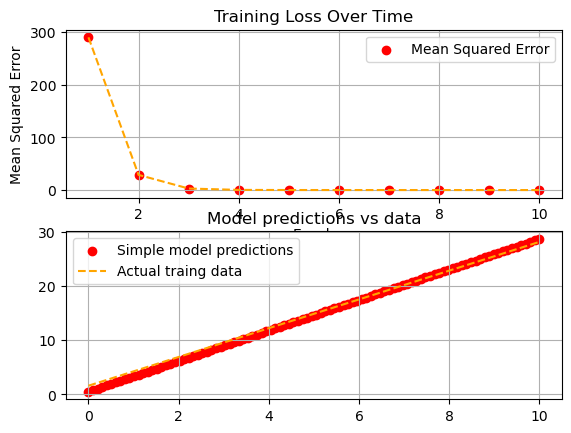

In [102]:
from matplotlib import pyplot as plt

model_preds = Simple.forward(inputs)

fig , axs = plt.subplots(2)

axs[0].scatter(x=time, y=mse_over_time, color='red', label='Mean Squared Error')
axs[0].plot(time, mse_over_time, color='orange', linestyle='--')

axs[0].set_title("Training Loss Over Time")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Mean Squared Error")
axs[0].grid(True)
axs[0].legend()


axs[1].scatter(x=x_axis_for_data, y=model_preds, color='red', label='Simple model predictions')
axs[1].plot(x_axis_for_data,  targets.flatten(), color='orange', linestyle='--', label='Actual traing data')

axs[1].set_title("Model predictions vs data")
axs[1].grid(True)
axs[1].legend()


plt.show()

### **MNIST** classifcation through gradient decent
In this section a sample of the MNIST dataset is used to show how a Model can be trained using this library. After a few itterations - to demonstrate the functionality of this library - a pretrained model (trained on a larger dataset using only this library) will be loaded to show of more accurate classifcaiton while saving time and compute.

#### Setting up the data

In [ ]:
from pandas import read_csv
from pathlib import Path

data_dir = Path("reduced_MNIST_data")
#Temp
data_dir = r"C:\Users\acart\OneDrive\Desktop\CodingProjects\mnist\mnist_train.csv"

data_frame = read_csv(data_dir)
data_frame = data_frame.drop(columns=["Unnamed: 0"], errors="ignore")

data = data_frame.to_numpy()
m, n = data.shape

data_dev = data[0:200]
Y_dev = data_dev[:, 0].astype(int)
X_dev = data_dev[:, 1:].astype(np.float32) / 255.0

data_train = data[800:m]
Y_train = data_train[:, 0].astype(int)
X_train = data_train[:, 1:].astype(np.float32) / 255.0

print(X_train.shape)
print(Y_train.shape)
m_train, n_features = X_train.shape

def one_hot(Y):
    Y = np.asarray(Y, dtype=int)
    one_hot_Y = np.zeros((Y.size, Y.max() + 1), dtype=np.float32)
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

Y_train = one_hot(Y_train)

print(X_train.shape)
print(Y_train.shape)

(200, 784)
(200,)
(200, 784)
(200, 10)


#### Creating and training a model

In [104]:
model = main.Model(input_size=784, output_size=10, hidden_size=16,
              number_of_layers=4, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=0, initialisation_function="He")

for i in range(250):
    output = model.forward(X_train)
    loss = main.CrossEntropyLoss(output, Y_train)
    model.backwards(output, Y_train, main.CrossEntropyLoss)
    model.update_parramaters(5e-2)
    if (i+1) % 10 == 0 or i == 0: 
        print(f"Epoch: {i+1}    Loss: {loss}    Accuracy: {round(np.exp(-loss) * 100, 3)}%")

# The final loss of 90.395% is a result of overfitting.


Epoch: 1    Loss: 2.772719455552714    Accuracy: 6.249%
Epoch: 10    Loss: 2.4145860963632284    Accuracy: 8.94%
Epoch: 20    Loss: 2.196326632588962    Accuracy: 11.121%
Epoch: 30    Loss: 1.9857544500265283    Accuracy: 13.728%
Epoch: 40    Loss: 1.8219972914569587    Accuracy: 16.17%
Epoch: 50    Loss: 1.6545070573144636    Accuracy: 19.119%
Epoch: 60    Loss: 1.4787130573537604    Accuracy: 22.793%
Epoch: 70    Loss: 1.3016799325321469    Accuracy: 27.207%
Epoch: 80    Loss: 1.1363264772246218    Accuracy: 32.1%
Epoch: 90    Loss: 0.9878290373430313    Accuracy: 37.238%
Epoch: 100    Loss: 0.8537240219731714    Accuracy: 42.583%
Epoch: 110    Loss: 0.7268645114592741    Accuracy: 48.342%
Epoch: 120    Loss: 0.6016451487689402    Accuracy: 54.791%
Epoch: 130    Loss: 0.5131996646445279    Accuracy: 59.858%
Epoch: 140    Loss: 0.42398980951933013    Accuracy: 65.443%
Epoch: 150    Loss: 0.36266530565548694    Accuracy: 69.582%
Epoch: 160    Loss: 0.3150066783471628    Accuracy: 72.97

In [ ]:
#Tempory
from pickle import dump, load
parameters_path = Path("pretrained_model_parameters.pkl")

# Save parameters
with parameters_path.open("wb") as file:
    dump(model.parramaters, file)

print(f"Saved to {parameters_path}")

#### Showcaseing the data from the model

In [105]:
print("Model parramaters for Layer 3:")
print(model.parramaters["Layer 3"])

print("Model gradients for Layer 3:")
print(model.gradients["Layer 3"])

Model parramaters for Layer 3:
{'weights': array([[ 0.03795326, -0.04278543,  0.24156375,  0.03302462, -0.18708582,
         0.12519953,  0.46103364,  0.32947642, -0.26065   , -0.4293868 ,
        -0.21959619,  0.01305107, -0.813838  , -0.07735454, -0.44057548,
        -0.25188276],
       [-0.06324492, -0.12466601,  0.1361187 ,  0.40261415, -0.13491605,
         0.63884264, -0.23518184,  0.00287945,  0.23279692,  0.242234  ,
        -0.26281014, -0.3283354 , -0.25493354,  0.07785073, -0.49077183,
        -0.09921885],
       [-0.05893427,  0.10844883,  0.14292826,  0.05816836, -0.14751936,
        -0.00349623,  0.27717718,  0.57985675, -0.5354128 ,  0.57044154,
         0.4859399 ,  0.2665239 ,  0.2115868 , -0.11098848,  0.58484125,
         0.73609394],
       [ 0.8364082 ,  0.74618393,  0.10427959, -0.32082143,  0.04010111,
         0.53781223, -0.45550457, -0.25023752, -0.23291689,  0.430222  ,
        -0.40255347, -0.25207356, -0.06761496, -0.41358742,  1.0126164 ,
        -0.0927

#### Loading a pretrianed model

In [ ]:
paramaters_path = Path("pretrained_model_parameters.pkl")

with paramaters_path.open("rb") as file:
    loaded_paramaters = load(file)

model.set_parramaters(loaded_paramaters)

<bound method Model.set_parramaters of <main.Model object at 0x00000133F7ED1050>>